In [70]:
# 1. 导入模块
import seaborn as sns       #导入seaborn库
import numpy as np          #导入numpy库
import matplotlib.pyplot as plt #导入matplotlib.pyplot库
import pandas as pd         #导入pandas库
#将生成的静态图嵌入notebook中
%matplotlib inline
plt.rcParams['font.sans-serif']=['Microsoft YaHei']   # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus']=False     # 用来正常显示负号

In [ ]:
# 2. 获取数据
titanic=sns.load_dataset('titanic')  #读入seaborn自带的泰坦尼克号数据
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [72]:
# 3. 数据可视化
# （1）查看有无缺失值
# 使用isnull().sum()检查各列缺失值情况
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

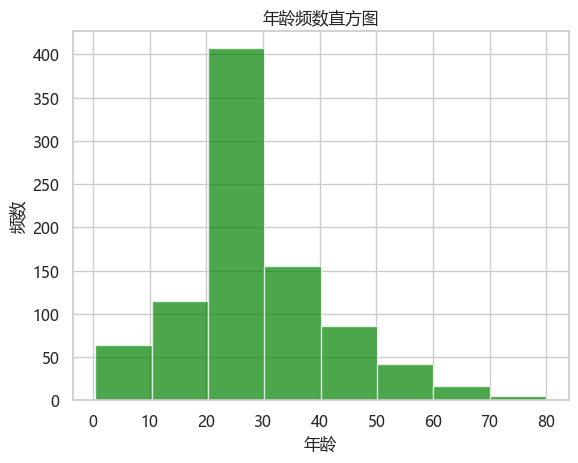

In [73]:
# （2）用年龄的均值进行缺失值的填充，输出年龄频数直方图
# 计算年龄均值
age_mean = titanic['age'].mean()
# 使用fillna()函数用均值填充age列的缺失值
titanic['age'] = titanic['age'].fillna(value=age_mean)

# 绘制年龄频数直方图
age_random = titanic['age'].values      # 获取年龄数据
plt.hist(age_random, bins=8, color='g', alpha=0.7) # 绘制直方图
plt.title('年龄频数直方图')
plt.xlabel('年龄')
plt.ylabel('频数')
plt.show()  # 显示图像

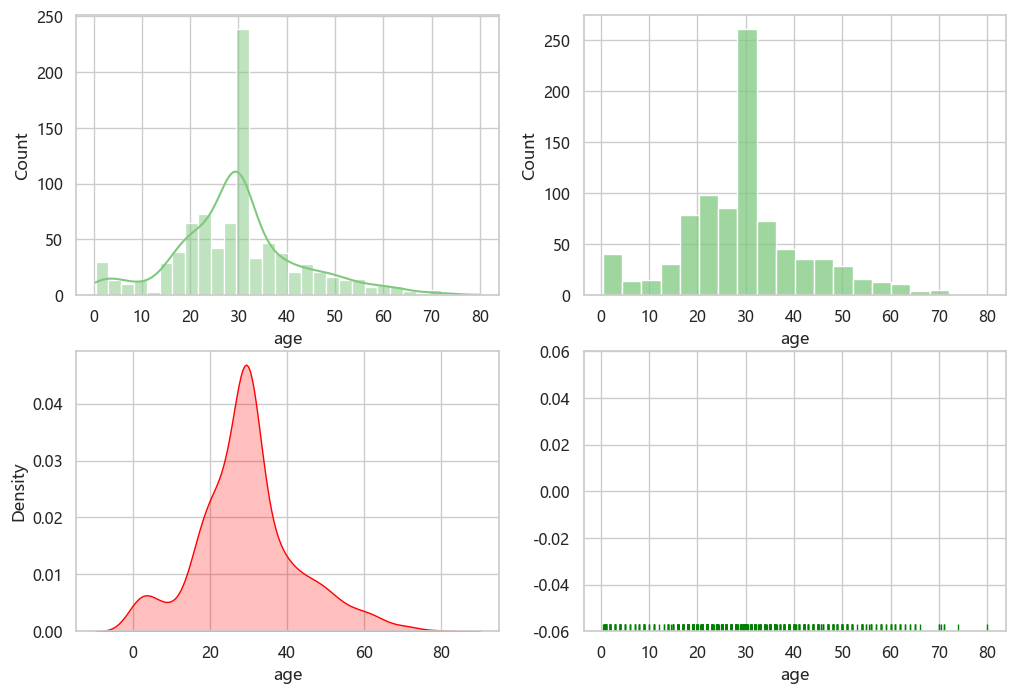

In [74]:
# （3）进行年龄分布的可视化
# 参考day12直方图和核密度曲线图代码模板
#distplot参数说明：a表示数据；bins表示柱体的数量；hist表示是否显示柱体；kde表示是否绘制核密度曲线；rug表示是否显示边际地毯图
fig,axes = plt.subplots(2,2,figsize=(12,8))   #子图.fig:外框，axes:内框
# 直方图嵌套密度曲线图
sns.histplot(titanic['age'],ax=axes[0,0],kde=True)  
#不带密度图, bins设置分段
sns.histplot(titanic['age'], ax=axes[0,1], bins=20, kde=False)
 # kdeplot( )为密度曲线图   shade  阴影  
sns.kdeplot(titanic['age'], ax=axes[1,0], fill=True, color='r')   
# rugplot 边际毛毯图
sns.rugplot(titanic['age'], ax=axes[1,1], color='g') 
plt.show()  

In [75]:
# （4）显示登船地点（S、C、Q）的人数
# 使用value_counts()统计各登船地点的人数
embarked_counts = titanic['embarked'].value_counts()
embarked_counts

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [76]:
# （5）对登船地点进行缺失值的填充（填充为S）
# embarked为登船地点，S表示Southampton（南安普顿）
titanic['embarked'] = titanic['embarked'].fillna(value='S')
# 填充后再次检查缺失值
titanic['embarked'].isnull().sum()

np.int64(0)

In [77]:
# （6）对于deck字段，由于缺失值太多，将其删除
# deck为船舱甲板编号，缺失值多达688个
titanic = titanic.drop(columns='deck')
# 删除后查看数据形状
titanic.shape

(891, 14)

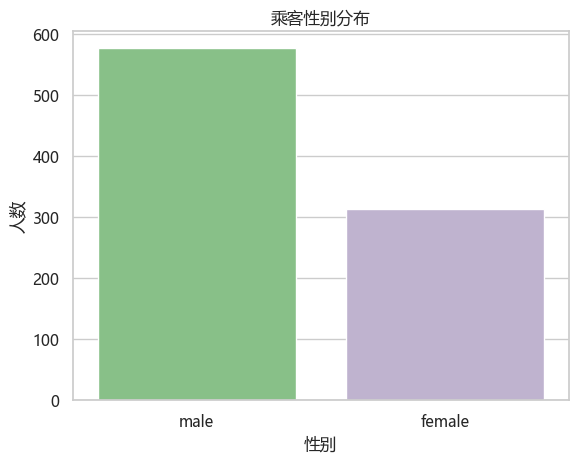

In [78]:
# 4. 数据探索
# （1）可视化乘客的性别分布
plt.rcParams['font.sans-serif']=['Microsoft YaHei']   # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus']=False     # 用来正常显示负号

# 使用countplot统计乘客性别分布
sns.countplot(x='sex', data=titanic, hue='sex', palette='Accent', legend=False)
plt.title('乘客性别分布')
plt.xlabel('性别')
plt.ylabel('人数')
plt.show()

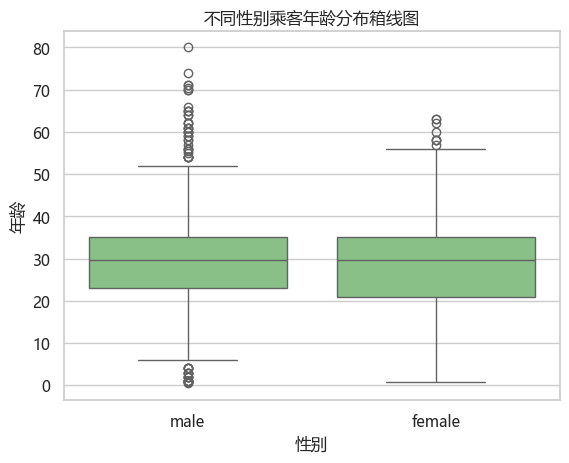

In [79]:
# （2）基于性别，绘制乘客年龄分布箱线图
sns.boxplot(x=titanic['sex'],y=titanic['age'],data=titanic)
plt.title('不同性别乘客年龄分布箱线图')
plt.xlabel('性别')
plt.ylabel('年龄')
plt.show()

In [80]:
# （3）对船舱等级进行计数
# pclass为船舱等级：1=一等舱，2=二等舱，3=三等舱
class_counts = titanic['class'].value_counts()
class_counts

class
Third     491
First     216
Second    184
Name: count, dtype: int64

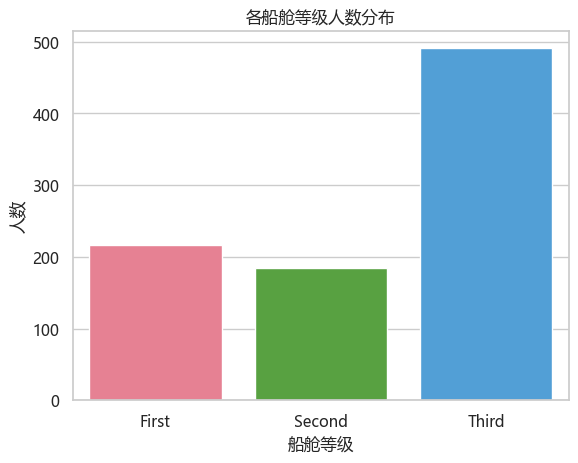

In [81]:
# 绘制船舱等级人数柱形图
# 参考day12条形图代码模板
sns.countplot(x='class', data=titanic, hue='class', palette='husl', legend=False)
plt.title('各船舱等级人数分布')
plt.xlabel('船舱等级')
plt.ylabel('人数')
plt.show()

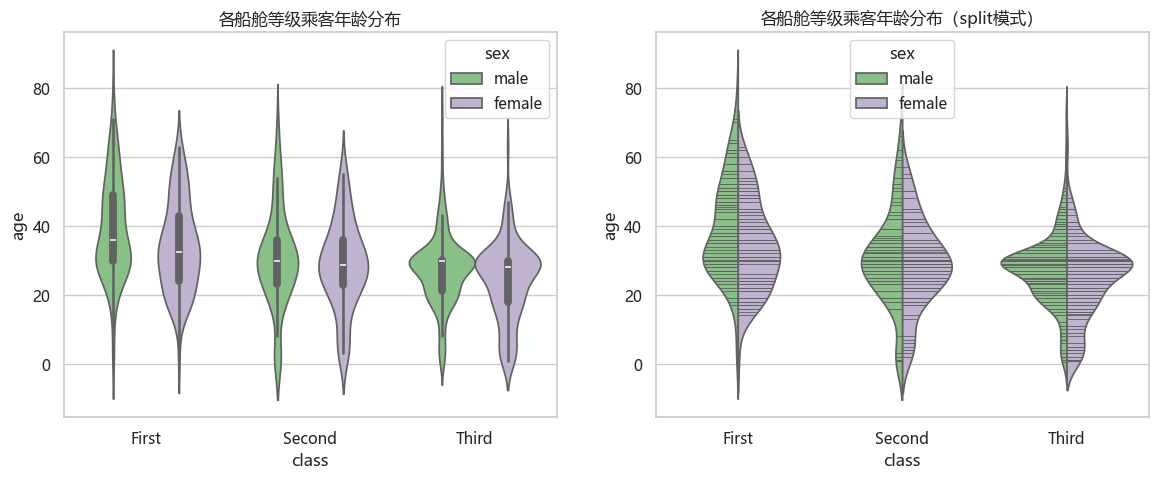

In [82]:
# （4）结合船舱等级，绘制乘客年龄分布的小提琴图
sns.set(style='whitegrid', palette='Accent')
fig, axes = plt.subplots(1,2,figsize=(14, 5))  #子图
plt.rcParams['font.sans-serif']=['Microsoft YaHei']   # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus']=False     # 用来正常显示负号
#split:小提琴是否分成两半，默认false
#inner：控制小提琴图内部显示的统计信息，可选值包括：'box': 显示微型箱线图（默认）。'quartiles': 显示四分位线。
sns.violinplot(x='class', y='age', hue='sex', data=titanic,ax=axes[0])
axes[0].set_title('各船舱等级乘客年龄分布')
#split参数可以将分类数据进行切分，琴形图两边的颜色代表不同的类别,inner参数对每个数据可视化
sns.violinplot(x='class', y='age', hue='sex', data=titanic,split=True,inner='stick', ax=axes[1])
axes[1].set_title('各船舱等级乘客年龄分布（split模式）')
plt.show()

In [83]:
# （5）对年龄进行分级，分开小孩和老人的数据
# 使用cut()函数对年龄进行分段：<=18为小孩，19-60为成人，>60为老人
age_bins = [0, 18, 60, 100]
age_labels = ['小孩(<=18)', '成人(19-60)', '老人(>60)']
titanic['age_group'] = pd.cut(titanic['age'], bins=age_bins, labels=age_labels)
# 查看各年龄段人数
age_group_counts = titanic['age_group'].value_counts()
age_group_counts

age_group
成人(19-60)    730
小孩(<=18)     139
老人(>60)       22
Name: count, dtype: int64

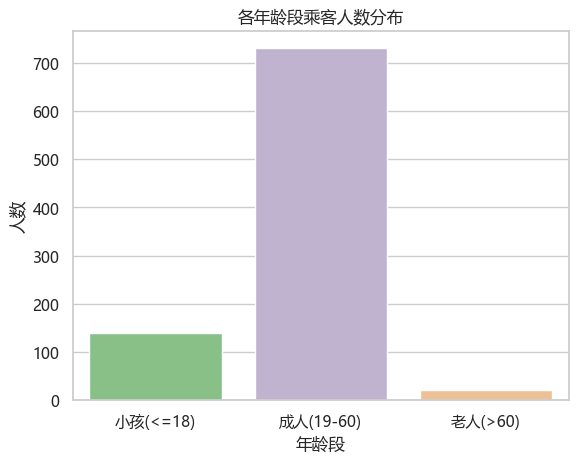

In [84]:
# （6）对分级后的年龄可视化
# 使用countplot统计各年龄段人数
sns.countplot(x='age_group', data=titanic, hue='age_group', palette='Accent', legend=False)
plt.title('各年龄段乘客人数分布')
plt.xlabel('年龄段')
plt.ylabel('人数')
plt.show()

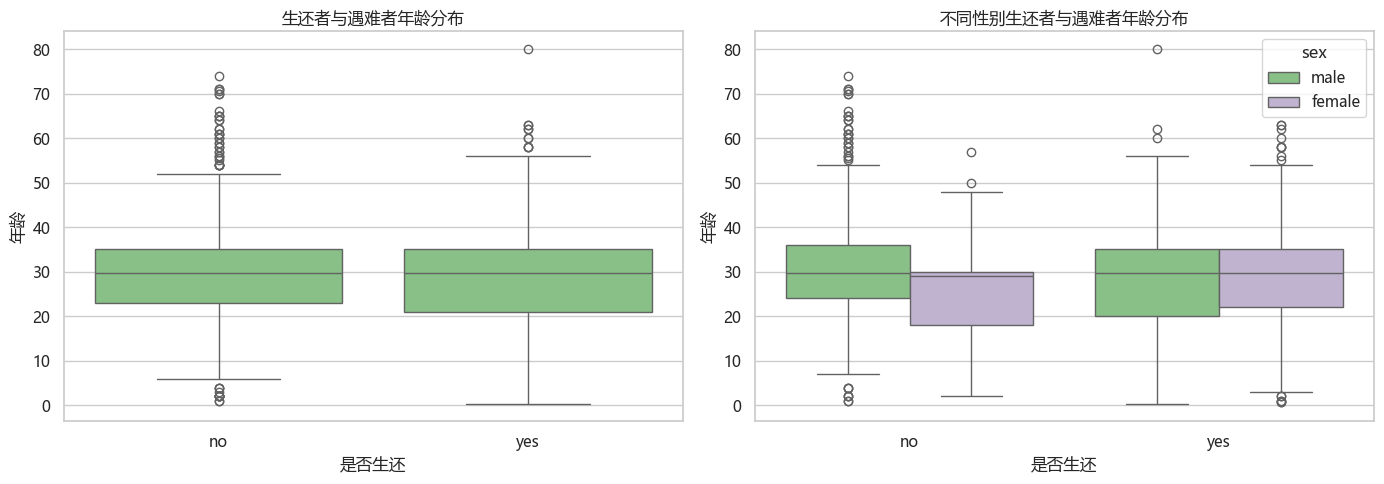

In [85]:
# （7）分析乘客年龄与生还乘客之间的关系
# 使用箱线图比较生还者与遇难者的年龄分布
# survived: 0=遇难, 1=生还；alive: no=遇难, yes=生还
fig, axes = plt.subplots(1,2,figsize=(14, 5))

# 子图1：基于生还状态的年龄箱线图
sns.boxplot(x='alive', y='age', data=titanic, ax=axes[0])
axes[0].set_title('生还者与遇难者年龄分布')
axes[0].set_xlabel('是否生还')
axes[0].set_ylabel('年龄')

# 子图2：结合性别和生还状态的年龄箱线图
sns.boxplot(x='alive', y='age', hue='sex', data=titanic, ax=axes[1])
axes[1].set_title('不同性别生还者与遇难者年龄分布')
axes[1].set_xlabel('是否生还')
axes[1].set_ylabel('年龄')

plt.tight_layout()
plt.show()

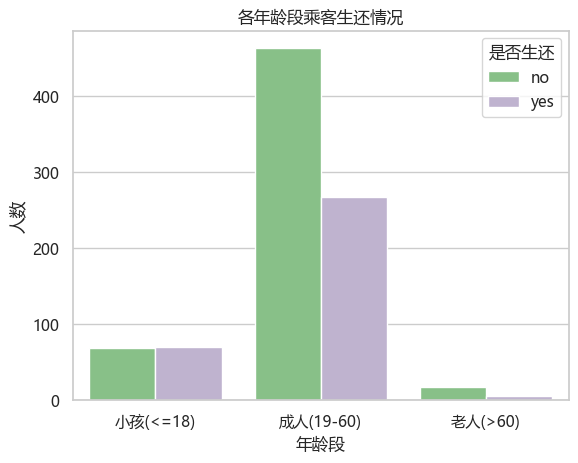

In [ ]:
# 分析各年龄段生还情况
# 使用countplot查看不同年龄段的生还人数
sns.countplot(x='age_group', hue='alive', data=titanic, palette='Accent')
plt.title('各年龄段乘客生还情况')
plt.xlabel('年龄段')
plt.ylabel('人数')
plt.legend(title='是否生还')
plt.show()